# 02 — Inference and Error Analysis

**Model:** `best.pt` from run 2 (YOLO11s, 1280 px) — see `notebooks/01_Training.ipynb`
**Dataset:** `interior-wall-defects` v1, same release, same SHA256

---

### What this notebook does

1. Downloads the dataset **and the trained weights** from the same public release. No key.
2. Runs inference **once** at a low confidence floor, keeping every detection.
3. Matches predictions to ground truth per image and accounts for every box as
   **TP / False Negative / False Positive / Class Confusion**.
4. Ranks every validation and test image by failure type, so the examples in
   `docs/error_analysis.md` are **selected by the data, not by eye**.
5. Draws ground-truth and prediction overlays for the selected cases.
6. Sweeps the confidence threshold, because a screening tool's operating point is a
   decision, not a default.
7. Runs the model on the **12 holdout frames** that were never uploaded to Roboflow.

### Why the ranking step matters

Picking three false negatives by scrolling through images selects for what is *visually
striking*, which is not the same as what is *representative*. Sorting the whole split by
measured failure counts removes that bias, and the sort itself is reproducible.

> Runtime: **GPU** recommended but not required — inference on ~100 images runs on CPU.


---
## **1. Environment**


In [1]:
import subprocess, sys, platform
from importlib.metadata import version, PackageNotFoundError

ULTRALYTICS_VERSION = "8.4.166"   # pinned: the version that produced the reported results

try:
    installed = version("ultralytics")
except PackageNotFoundError:
    installed = None

if installed != ULTRALYTICS_VERSION:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    f"ultralytics=={ULTRALYTICS_VERSION}"], check=True)

import ultralytics, torch, numpy as np, pandas as pd
from ultralytics import YOLO
from PIL import Image, ImageDraw, ImageFont

print(f"python       {platform.python_version()}")
print(f"ultralytics  {ultralytics.__version__}")
print(f"torch        {torch.__version__}")
print(f"cuda         {torch.cuda.is_available()}")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
python       3.13.15
ultralytics  8.4.166
torch        2.11.0+cpu
cuda         False


---
## **2. Configuration**

Two artifacts are pinned here, each by URL **and** hash: the dataset and the weights. Together
they fix everything this notebook depends on — the same bytes in, the same predictions out.

`MODEL_SHA256` may be blank on your first run. The download cell prints the hash it computed;
paste that value back here and the notebook becomes self-verifying from then on.

### The two thresholds

`CONF_FLOOR` is the confidence below which a detection is discarded during inference. It is
set **very low on purpose** (0.01), so that section 8 can sweep thresholds without re-running
the model. It is not the operating point.

`CONF` is the operating point actually reported — the threshold at which the error accounting
in sections 6 and 7 is done. 0.25 matches the default Ultralytics uses for its confusion
matrix, so these numbers are comparable with `01_Training.ipynb`.

`IOU_MATCH` is how much overlap counts as "the same object" — 0.45, again matching the
training notebook's confusion matrix.


In [2]:
from pathlib import Path

# --- dataset (same release, same bytes as training) ---------------------------
DATASET_URL     = "https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/interior-wall-defects-v1-yolo11.zip"
DATASET_SHA256  = "9137b89d2f406adf1fa7dbfc6bf5a2e95db396d39c26a8c80d248a2f0b8b8a42"
DATASET_VERSION = "v1"

# --- trained weights ----------------------------------------------------------
# Attach best.pt to the v1.0 release as a second asset, then paste its URL here.
# Leave MODEL_SHA256 empty on the first run; the download cell prints the value.
MODEL_URL    = "https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/best-run2.pt"
MODEL_SHA256 = "cc1d5096124f32bc7783d86a817394fc08501ef8291b2fa6c76f9dc1e720fe4f"          # <-- paste the printed hash here after the first run
MODEL_LOCAL  = "best.pt"   # fallback: upload best.pt to the runtime if MODEL_URL 404s

# --- holdout: 12 frames never uploaded to Roboflow, never seen by any split ----
# Optional. Publish as a release asset, or upload a folder named "holdout" to
# the runtime. Skipped silently if neither exists, so Run All never breaks.
HOLDOUT_URL = ""           # e.g. ".../releases/download/v1.0/holdout.zip"

# --- classes, in the export's index order --------------------------------------
EXPORT_CLASSES = ["blistering", "crack", "damp_patch", "mould", "peeling_paint"]

# --- inference ------------------------------------------------------------------
IMGSZ      = 1280    # must match training: a different imgsz is a different model
CONF_FLOOR = 0.01    # keep almost everything, so section 8 can sweep offline
CONF       = 0.25    # the reported operating point
IOU_MATCH  = 0.45    # overlap counting as the same object
IOU_NMS    = 0.70    # non-max suppression; Ultralytics default

# --- paths ----------------------------------------------------------------------
ROOT      = Path("/content") if Path("/content").exists() else Path.cwd()
ZIP_PATH  = ROOT / "dataset.zip"
DATA_DIR  = ROOT / "dataset"
WEIGHTS   = ROOT / "best.pt"
EVIDENCE  = ROOT / "evidence_inference"
OVERLAYS  = EVIDENCE / "overlays"
OVERLAYS.mkdir(parents=True, exist_ok=True)

print(f"root       {ROOT}")
print(f"evidence   {EVIDENCE}")
print(f"conf floor {CONF_FLOOR}   reported conf {CONF}   iou match {IOU_MATCH}")

root       /content
evidence   /content/evidence_inference
conf floor 0.01   reported conf 0.25   iou match 0.45


---
## **3. Dataset — download, verify, unpack**

Identical to `01_Training.ipynb` #3–#5, condensed. The checksum assertion is the important
line: it guarantees the images being scored here are the same images the model was trained
and validated against.


In [3]:
import hashlib, urllib.request, shutil, zipfile, yaml

def sha256_of(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def fetch(url, dest):
    if dest.exists():
        print(f"{dest.name} already present")
        return
    print(f"downloading {url}")
    with urllib.request.urlopen(url) as r, open(dest, "wb") as f:
        shutil.copyfileobj(r, f)

fetch(DATASET_URL, ZIP_PATH)
digest = sha256_of(ZIP_PATH)
assert digest.lower() == DATASET_SHA256.strip().lower(), (
    f"CHECKSUM MISMATCH\n  expected {DATASET_SHA256.lower()}\n  actual   {digest}"
)
print(f"dataset checksum OK  ({ZIP_PATH.stat().st_size/1e6:.1f} MB)")

if DATA_DIR.exists():
    shutil.rmtree(DATA_DIR)
DATA_DIR.mkdir(parents=True)
with zipfile.ZipFile(ZIP_PATH) as z:
    z.extractall(DATA_DIR)

YAML_PATH = sorted(DATA_DIR.rglob("data.yaml"))[0]
DATA_ROOT = YAML_PATH.parent

with open(YAML_PATH) as f:
    cfg = yaml.safe_load(f)

exported = cfg.get("names")
assert exported == EXPORT_CLASSES, (
    f"CLASS ORDER CHANGED\n  exported: {exported}\n  expected: {EXPORT_CLASSES}"
)

SPLIT_DIRS = {}
for split, keys in [("train", ["train"]), ("val", ["valid", "val"]), ("test", ["test"])]:
    for k in keys:
        d = DATA_ROOT / k / "images"
        if d.is_dir():
            SPLIT_DIRS[split] = d
            break

print(f"class order OK: {exported}")
for s, d in SPLIT_DIRS.items():
    n = len([p for p in d.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
    print(f"  {s:<6} {n:>4} images")

downloading https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/interior-wall-defects-v1-yolo11.zip
dataset checksum OK  (22.4 MB)
class order OK: ['blistering', 'crack', 'damp_patch', 'mould', 'peeling_paint']
  train   134 images
  val      44 images
  test     46 images


---
## **4. Weights — download and verify**

If `MODEL_URL` 404s, the cell falls back to a local `best.pt` you upload to the runtime — so
you can work before publishing. **That fallback is not reproducible**, and the cell says so
loudly, because a notebook that quietly depends on a file only you possess is the problem this
whole structure exists to avoid.


In [4]:
import urllib.error

got_remote = False
if MODEL_URL and not WEIGHTS.exists():
    try:
        fetch(MODEL_URL, WEIGHTS)
        got_remote = True
    except (urllib.error.HTTPError, urllib.error.URLError) as e:
        print(f"could not fetch weights from the release: {e}")

if not WEIGHTS.exists():
    local = ROOT / MODEL_LOCAL
    assert local.exists(), (
        f"No weights. Either publish best.pt as a release asset and set MODEL_URL, "
        f"or upload {MODEL_LOCAL} to {ROOT}."
    )
    if local != WEIGHTS:
        shutil.copy2(local, WEIGHTS)
    print("\n!! Using a LOCALLY UPLOADED best.pt.")
    print("   This notebook is NOT reproducible by anyone else in this state.")
    print("   Attach best.pt to the v1.0 release and set MODEL_URL.")

model_digest = sha256_of(WEIGHTS)
print(f"\nweights   {WEIGHTS.name}  ({WEIGHTS.stat().st_size/1e6:.1f} MB)")
print(f"sha256    {model_digest}")

if MODEL_SHA256.strip():
    assert model_digest.lower() == MODEL_SHA256.strip().lower(), (
        "WEIGHTS CHECKSUM MISMATCH — these are not the reported weights."
    )
    print("weights checksum OK")
else:
    print("\n>> MODEL_SHA256 is empty. Paste the hash above into the config cell")
    print("   so future runs verify the weights instead of trusting the URL.")

model = YOLO(str(WEIGHTS))
NAMES = model.names
print(f"\nmodel classes: {NAMES}")

downloading https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/best-run2.pt

weights   best.pt  (19.3 MB)
sha256    cc1d5096124f32bc7783d86a817394fc08501ef8291b2fa6c76f9dc1e720fe4f

>> MODEL_SHA256 is empty. Paste the hash above into the config cell
   so future runs verify the weights instead of trusting the URL.

model classes: {0: 'blistering', 1: 'crack', 2: 'damp_patch', 3: 'mould', 4: 'peeling_paint'}


---
## **5. Inference — one pass, low floor**

The model runs **once** over validation and test at `CONF_FLOOR = 0.01`, and every detection
is kept in a table. Everything downstream — the error accounting, the candidate ranking, the
threshold sweep — is computed from that table.

One pass rather than one per threshold: the sweep in section 8 would otherwise re-run the
model a dozen times and, more importantly, the numbers at different thresholds would come from
different inference passes rather than from the same predictions filtered differently.


In [5]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def images_in(split):
    d = SPLIT_DIRS[split]
    return sorted(p for p in d.iterdir() if p.suffix.lower() in IMG_EXT)

def label_for(img_path):
    return img_path.parent.parent / "labels" / f"{img_path.stem}.txt"

def load_gt(img_path, w, h):
    """Ground-truth boxes in pixel xyxy, plus class ids."""
    lp = label_for(img_path)
    boxes, cls = [], []
    if lp.exists():
        for line in lp.read_text().splitlines():
            if not line.strip():
                continue
            p = line.split()
            c = int(p[0])
            cx, cy, bw, bh = (float(v) for v in p[1:5])
            boxes.append([(cx - bw / 2) * w, (cy - bh / 2) * h,
                          (cx + bw / 2) * w, (cy + bh / 2) * h])
            cls.append(c)
    return (np.array(boxes, dtype=float).reshape(-1, 4),
            np.array(cls, dtype=int))

gt_rows, pred_rows = [], []

for split in ["val", "test"]:
    if split not in SPLIT_DIRS:
        continue
    paths = images_in(split)
    print(f"{split}: {len(paths)} images", end=" ", flush=True)

    results = model.predict(source=[str(p) for p in paths], imgsz=IMGSZ,
                            conf=CONF_FLOOR, iou=IOU_NMS, verbose=False, stream=True)

    for img_path, r in zip(paths, results):
        h, w = r.orig_shape
        gb, gc = load_gt(img_path, w, h)
        for (x1, y1, x2, y2), c in zip(gb, gc):
            gt_rows.append(dict(split=split, image=img_path.name, cls=int(c),
                                x1=x1, y1=y1, x2=x2, y2=y2))
        b = r.boxes
        if b is not None and len(b):
            xyxy = b.xyxy.cpu().numpy()
            confs = b.conf.cpu().numpy()
            clss = b.cls.cpu().numpy().astype(int)
            for (x1, y1, x2, y2), cf, c in zip(xyxy, confs, clss):
                pred_rows.append(dict(split=split, image=img_path.name, cls=int(c),
                                      conf=float(cf), x1=x1, y1=y1, x2=x2, y2=y2))
    print("done")

GT   = pd.DataFrame(gt_rows)
PRED = pd.DataFrame(pred_rows)

print(f"\nground-truth boxes  {len(GT):>6}")
print(f"detections kept     {len(PRED):>6}  (at conf >= {CONF_FLOOR})")
print(f"detections at {CONF}  {len(PRED[PRED.conf >= CONF]):>6}")

val: 44 images done
test: 46 images done

ground-truth boxes     436
detections kept       5176  (at conf >= 0.01)
detections at 0.25     195


---
## **6. Error accounting, image by image**

Every ground-truth box and every prediction is assigned to exactly one category.

The matching is greedy by descending IoU — the highest-overlap pair is matched first, both
boxes are removed from the pool, and the process repeats. This is how Ultralytics does it and
how the COCO evaluator does it. One prediction can satisfy at most one ground-truth box.

Two passes over the same image:

- **class-aware** — a prediction may only match a ground-truth box of the same class. Produces
  True Positives, False Negatives and False Positives.
- **class-blind** — a prediction may match any ground-truth box. The pairs that match here but
  *not* in the class-aware pass are **Class Confusion**: the model found the object and named
  it wrongly.

That second pass is what separates "missed it" from "saw it, called it something else".
Without it, both land in the False Negative pile and the error analysis cannot tell them apart.


In [7]:
def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)))
    ax1, ay1, ax2, ay2 = a[:, 0:1], a[:, 1:2], a[:, 2:3], a[:, 3:4]
    bx1, by1, bx2, by2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]
    ix1 = np.maximum(ax1, bx1); iy1 = np.maximum(ay1, by1)
    ix2 = np.minimum(ax2, bx2); iy2 = np.minimum(ay2, by2)
    inter = np.clip(ix2 - ix1, 0, None) * np.clip(iy2 - iy1, 0, None)
    area_a = (ax2 - ax1) * (ay2 - ay1)
    area_b = (bx2 - bx1) * (by2 - by1)
    return inter / np.maximum(area_a + area_b - inter, 1e-9)

def greedy_match(gt, gtc, pr, prc, iou_thr, class_aware):
    """Return matched (gt_idx, pred_idx, iou) pairs, plus unmatched indices."""
    M = iou_matrix(gt, pr)
    if class_aware and M.size:
        M = np.where(gtc[:, None] == prc[None, :], M, 0.0)
    pairs, used_g, used_p = [], set(), set()
    if M.size:
        flat = np.argsort(-M, axis=None)
        for idx in flat:
            g, p = np.unravel_index(idx, M.shape)
            if M[g, p] < iou_thr:
                break
            if g in used_g or p in used_p:
                continue
            used_g.add(int(g)); used_p.add(int(p))
            pairs.append((int(g), int(p), float(M[g, p])))
    fn = [i for i in range(len(gt)) if i not in used_g]
    fp = [j for j in range(len(pr)) if j not in used_p]
    return pairs, fn, fp

def account(conf_thr):
    """Per-image error counts at a given confidence threshold."""
    rows, detail = [], []
    pred_at = PRED[PRED.conf >= conf_thr]
    for split in [s for s in ["val", "test"] if s in SPLIT_DIRS]:
        for img_path in images_in(split):
            name = img_path.name
            g = GT[(GT.split == split) & (GT.image == name)]
            p = pred_at[(pred_at.split == split) & (pred_at.image == name)]
            gb = g[["x1", "y1", "x2", "y2"]].to_numpy(dtype=float).reshape(-1, 4)
            gc = g["cls"].to_numpy(dtype=int)
            pb = p[["x1", "y1", "x2", "y2"]].to_numpy(dtype=float).reshape(-1, 4)
            pc = p["cls"].to_numpy(dtype=int)

            pairs, fn, fp = greedy_match(gb, gc, pb, pc, IOU_MATCH, class_aware=True)
            blind, _, _   = greedy_match(gb, gc, pb, pc, IOU_MATCH, class_aware=False)
            confused = [(gi, pi) for gi, pi, _ in blind if gc[gi] != pc[pi]]

            rows.append(dict(
                split=split, image=name,
                gt=len(gb), pred=len(pb),
                TP=len(pairs), FN=len(fn), FP=len(fp),
                confusion=len(confused),
                mean_iou=float(np.mean([i for _, _, i in pairs])) if pairs else 0.0,
                is_background=(len(gb) == 0),
            ))
            for gi, pi in confused:
                detail.append(dict(split=split, image=name,
                                   true=NAMES[int(gc[gi])], pred=NAMES[int(pc[pi])]))
    return pd.DataFrame(rows), pd.DataFrame(detail)

PER_IMAGE, CONFUSIONS = account(CONF)

summary = PER_IMAGE.groupby("split")[["gt", "pred", "TP", "FN", "FP", "confusion"]].sum()
summary["recall"]    = (summary["TP"] / summary["gt"].replace(0, np.nan)).round(3)
summary["precision"] = (summary["TP"] / summary["pred"].replace(0, np.nan)).round(3)
display(summary)

PER_IMAGE.to_csv(EVIDENCE / "per_image_errors.csv", index=False)
print(f"\nwrote {EVIDENCE / 'per_image_errors.csv'}")

if len(CONFUSIONS):
    print("\nClass confusions (found but misnamed):")
    display(CONFUSIONS.groupby(["true", "pred"]).size()
                      .rename("count").reset_index()
                      .sort_values("count", ascending=False))
else:
    print("\nNo class confusions at this threshold — every miss is a clean miss.")

,gt,pred,TP,FN,FP,confusion,recall,precision
split,,,,,,,,
test,73,51,1,72,50,7,0.014,0.020
val,363,144,38,325,106,20,0.105,0.264



wrote /content/evidence_inference/per_image_errors.csv

Class confusions (found but misnamed):


,true,pred,count
5,damp_patch,mould,11
2,blistering,mould,6
1,blistering,damp_patch,5
0,blistering,crack,1
3,crack,peeling_paint,1
4,damp_patch,blistering,1
6,peeling_paint,blistering,1
7,peeling_paint,mould,1


**Read `confusion` before concluding anything about recall.** A class confusion is a
different failure from a miss: the model localised the defect and named it wrongly. Counting
those as false negatives would overstate how blind the model is and understate how confused
it is, and the two have different fixes — more data for one, a better class definition for the
other.


---
## **7. Candidate cases for the error analysis**

Three ranked shortlists, one per failure mode. The ranking is the point: these are the images
the *data* nominates, not the ones that catch the eye.

- **False negatives** — images with the most missed boxes and no false positives. A clean
  miss, uncontaminated by other errors, is the clearest illustration.
- **False positives** — **background** frames (zero ground-truth boxes) that produced
  detections. These are the documented hard negatives from `areas.csv`: a box here means a
  confuser the model treats as a defect, which is the most interpretable false positive there
  is.
- **Class confusion** — images where a prediction overlapped a ground-truth box but named it
  differently.

Overlays are drawn with **ground truth in green, predictions in red**, so both are legible in
one image.


In [8]:
TOP_N = 5

fn_cases = (PER_IMAGE[(PER_IMAGE.FN > 0) & (PER_IMAGE.FP == 0) & (~PER_IMAGE.is_background)]
            .sort_values(["FN", "gt"], ascending=False).head(TOP_N))
fp_cases = (PER_IMAGE[(PER_IMAGE.is_background) & (PER_IMAGE.FP > 0)]
            .sort_values("FP", ascending=False).head(TOP_N))
cc_cases = (PER_IMAGE[PER_IMAGE.confusion > 0]
            .sort_values("confusion", ascending=False).head(TOP_N))

for label, df in [("FALSE NEGATIVES (clean misses)", fn_cases),
                  ("FALSE POSITIVES (on hard negatives)", fp_cases),
                  ("CLASS CONFUSION", cc_cases)]:
    print(f"\n=== {label} ===")
    if len(df):
        display(df[["split", "image", "gt", "pred", "TP", "FN", "FP", "confusion"]])
    else:
        print("  none found at this threshold")


=== FALSE NEGATIVES (clean misses) ===


,split,image,gt,pred,TP,FN,FP,confusion
31,val,KITCHEN-C_c20_bright_clean_7206_JPG.rf.5ba6590...,13,2,2,11,0,0
22,val,KITCHEN-B_c40_bright_clean_7186_JPG.rf.a75b24c...,8,1,1,7,0,0
16,val,KITCHEN-B_c20_bright_clean_7189_JPG.rf.a1ea788...,3,0,0,3,0,0
43,val,KITCHEN-D_c40_bright_clean_7166_JPG.rf.5e59da9...,3,0,0,3,0,0
56,test,LIVING-B_c20_bright_clean_7172_JPG.rf.91397752...,2,0,0,2,0,0



=== FALSE POSITIVES (on hard negatives) ===


,split,image,gt,pred,TP,FN,FP,confusion
0,val,HALLWAY-A_c40_bright_clean_7108_JPG.rf.08a505b...,0,1,0,0,1,0
48,test,LIVING-A_c20_bright_clean_7110_JPG.rf.ec781ebb...,0,1,0,0,1,0
61,test,LIVING-C_c10_bright_clean_7134_JPG.rf.5d5c9369...,0,1,0,0,1,0
78,test,OFFICE-A_c10_elec_clean_7113_JPG.rf.465cfb4e07...,0,1,0,0,1,0
89,test,OFFICE-D_c40_elec_clean_7112_JPG.rf.174f3f9a9e...,0,1,0,0,1,0



=== CLASS CONFUSION ===


,split,image,gt,pred,TP,FN,FP,confusion
87,test,OFFICE-C_c40_bright_clean_7179_JPG.rf.472392a6...,6,7,0,6,7,4
25,val,KITCHEN-C_c20_bright_clean_7153_JPG.rf.48a523e...,12,12,3,9,9,3
19,val,KITCHEN-B_c40_bright_clean_7182_JPG.rf.315915c...,11,3,0,11,3,2
6,val,HALLWAY-C_c40_bright_clean_7200_JPG.rf.654209f...,7,3,0,7,3,1
1,val,HALLWAY-A_ctx_bright_clean_7197_JPG.rf.ef1dbe1...,11,6,1,10,5,1


In [9]:
GT_COLOUR   = (40, 220, 90)
PRED_COLOUR = (255, 60, 60)

def _font(size):
    for p in ["/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
              "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf"]:
        try:
            return ImageFont.truetype(p, size)
        except OSError:
            continue
    return ImageFont.load_default()

def find_image(split, name):
    return SPLIT_DIRS[split] / name

def overlay(split, name, conf_thr=CONF, out_dir=OVERLAYS):
    img_path = find_image(split, name)
    im = Image.open(img_path).convert("RGB")
    w, h = im.size
    d = ImageDraw.Draw(im)
    lw = max(3, int(min(w, h) / 300))
    font = _font(max(18, int(min(w, h) / 45)))

    gb, gc = load_gt(img_path, w, h)
    for (x1, y1, x2, y2), c in zip(gb, gc):
        d.rectangle([x1, y1, x2, y2], outline=GT_COLOUR, width=lw)
        d.text((x1 + 3, max(0, y1 - font.size - 4)), f"GT {NAMES[int(c)]}",
               fill=GT_COLOUR, font=font)

    p = PRED[(PRED.split == split) & (PRED.image == name) & (PRED.conf >= conf_thr)]
    for _, r in p.iterrows():
        d.rectangle([r.x1, r.y1, r.x2, r.y2], outline=PRED_COLOUR, width=lw)
        d.text((r.x1 + 3, min(h - font.size, r.y2 + 3)),
               f"{NAMES[int(r.cls)]} {r.conf:.2f}", fill=PRED_COLOUR, font=font)

    d.text((10, 10), f"{split}/{name}   green = ground truth   red = prediction "
                     f"(conf >= {conf_thr})", fill=(255, 255, 255), font=font)

    out = Path(out_dir) / f"{split}_{Path(name).stem}_overlay.jpg"
    im.save(out, quality=88)
    return out

produced = []
for tag, df in [("FN", fn_cases), ("FP", fp_cases), ("CC", cc_cases)]:
    for _, r in df.iterrows():
        produced.append((tag, overlay(r.split, r.image)))

print(f"wrote {len(produced)} overlays to {OVERLAYS}")
for tag, p in produced:
    print(f"  {tag}  {p.name}")

wrote 15 overlays to /content/evidence_inference/overlays
  FN  val_KITCHEN-C_c20_bright_clean_7206_JPG.rf.5ba659057bcd1026d353af986e86adba_overlay.jpg
  FN  val_KITCHEN-B_c40_bright_clean_7186_JPG.rf.a75b24ccc131027e6c4dce6a109f26c2_overlay.jpg
  FN  val_KITCHEN-B_c20_bright_clean_7189_JPG.rf.a1ea788e26fa45ba3ca868ee84ecf52b_overlay.jpg
  FN  val_KITCHEN-D_c40_bright_clean_7166_JPG.rf.5e59da9f863b6b28e112c06e3bfcc1ad_overlay.jpg
  FN  test_LIVING-B_c20_bright_clean_7172_JPG.rf.9139775213779cfa4070ebd0fa77d72c_overlay.jpg
  FP  val_HALLWAY-A_c40_bright_clean_7108_JPG.rf.08a505b21c7ddff4dfea9ee90bfeab6a_overlay.jpg
  FP  test_LIVING-A_c20_bright_clean_7110_JPG.rf.ec781ebba7510fe7051c6cc67286c788_overlay.jpg
  FP  test_LIVING-C_c10_bright_clean_7134_JPG.rf.5d5c936960ad97e4a674a467e3761d76_overlay.jpg
  FP  test_OFFICE-A_c10_elec_clean_7113_JPG.rf.465cfb4e071c8f357005b432d62f471e_overlay.jpg
  FP  test_OFFICE-D_c40_elec_clean_7112_JPG.rf.174f3f9a9e03c7a3a611fef4ca0b1d01_overlay.jpg
  CC  


=== FN: val_KITCHEN-C_c20_bright_clean_7206_JPG.rf.5ba659057bcd1026d353af986e86adba_overlay.jpg ===


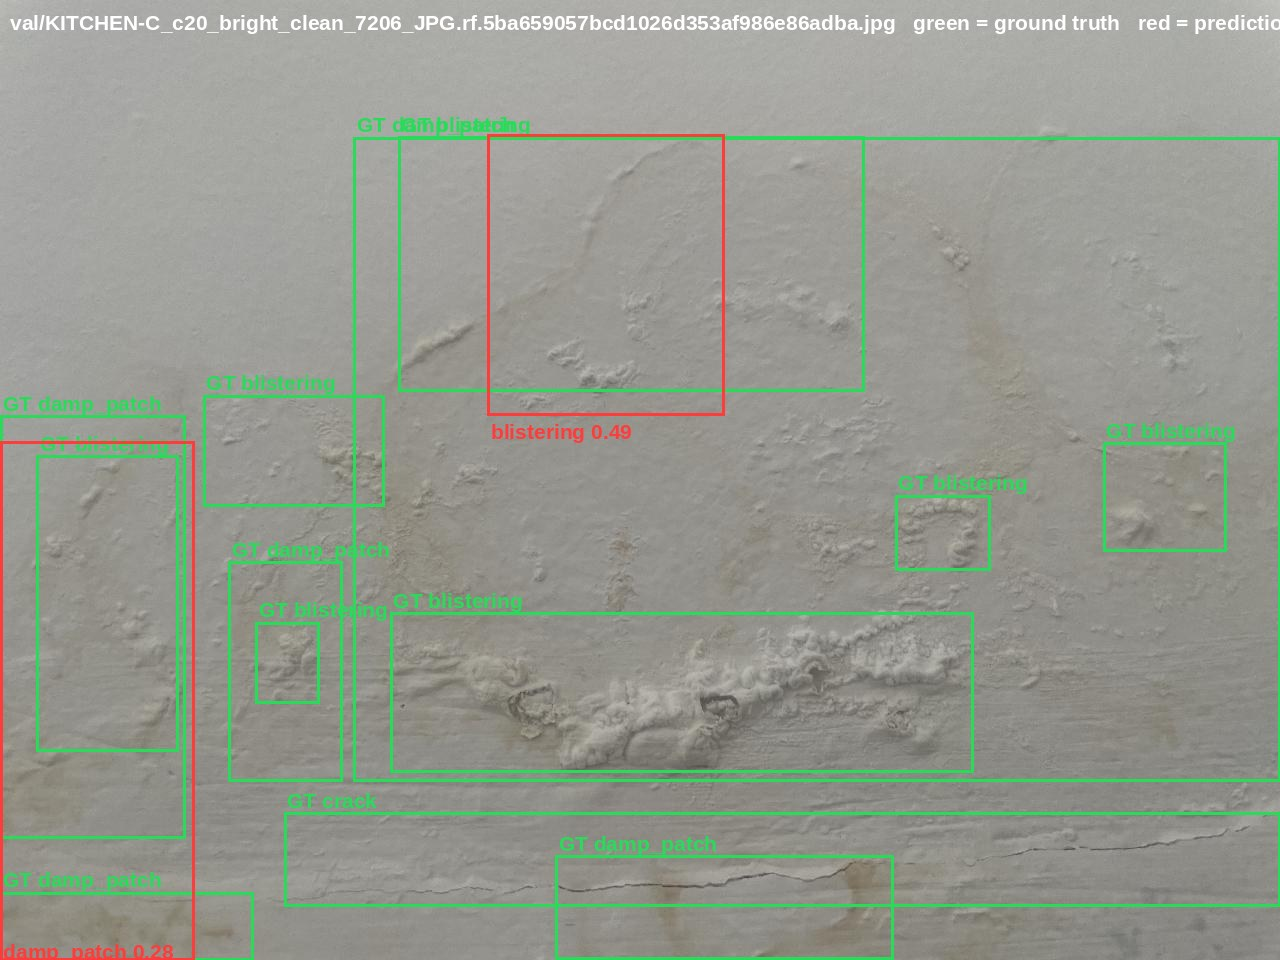


=== FN: val_KITCHEN-B_c40_bright_clean_7186_JPG.rf.a75b24ccc131027e6c4dce6a109f26c2_overlay.jpg ===


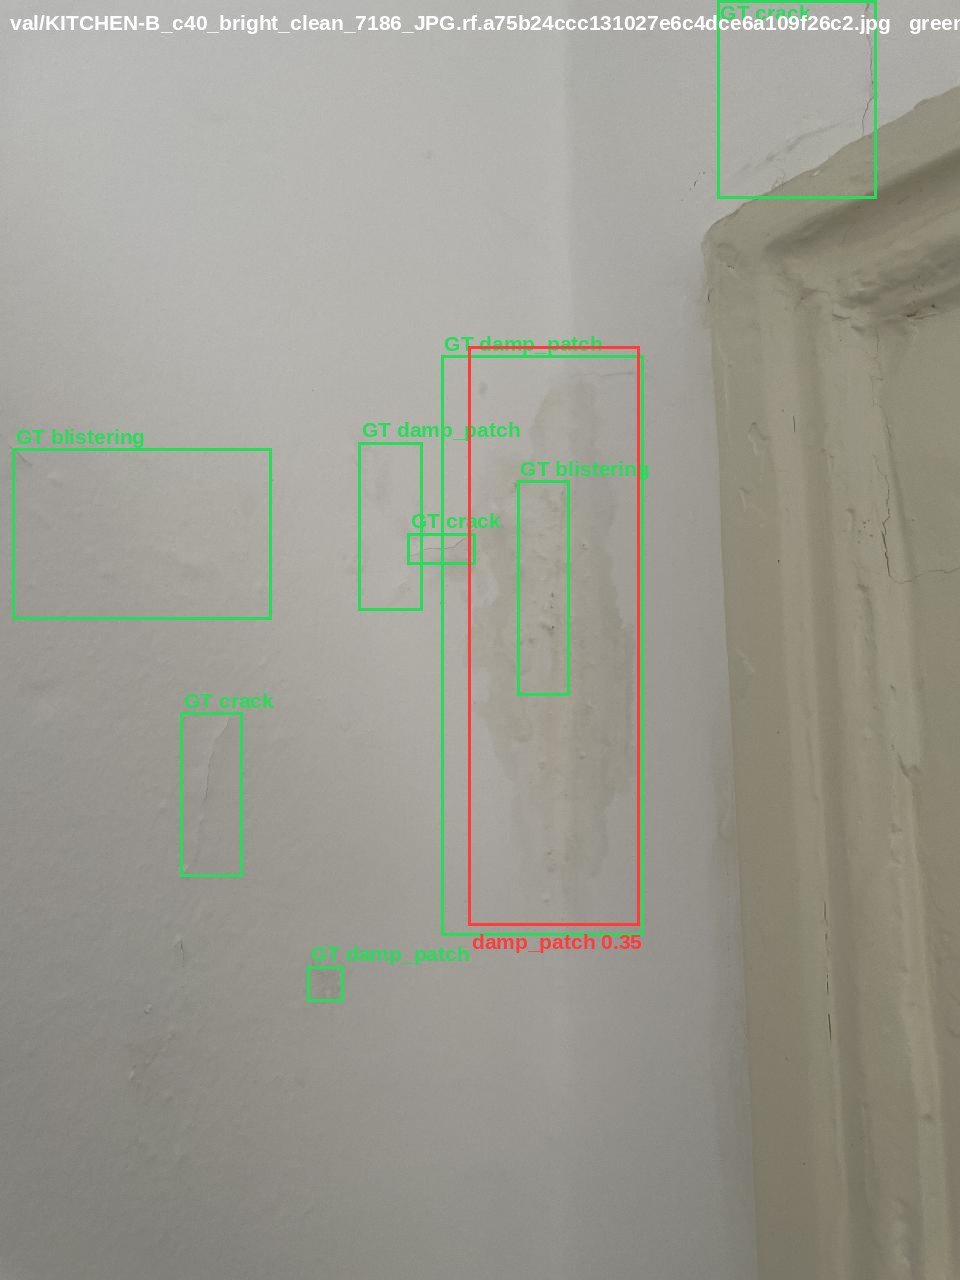


=== FN: val_KITCHEN-B_c20_bright_clean_7189_JPG.rf.a1ea788e26fa45ba3ca868ee84ecf52b_overlay.jpg ===


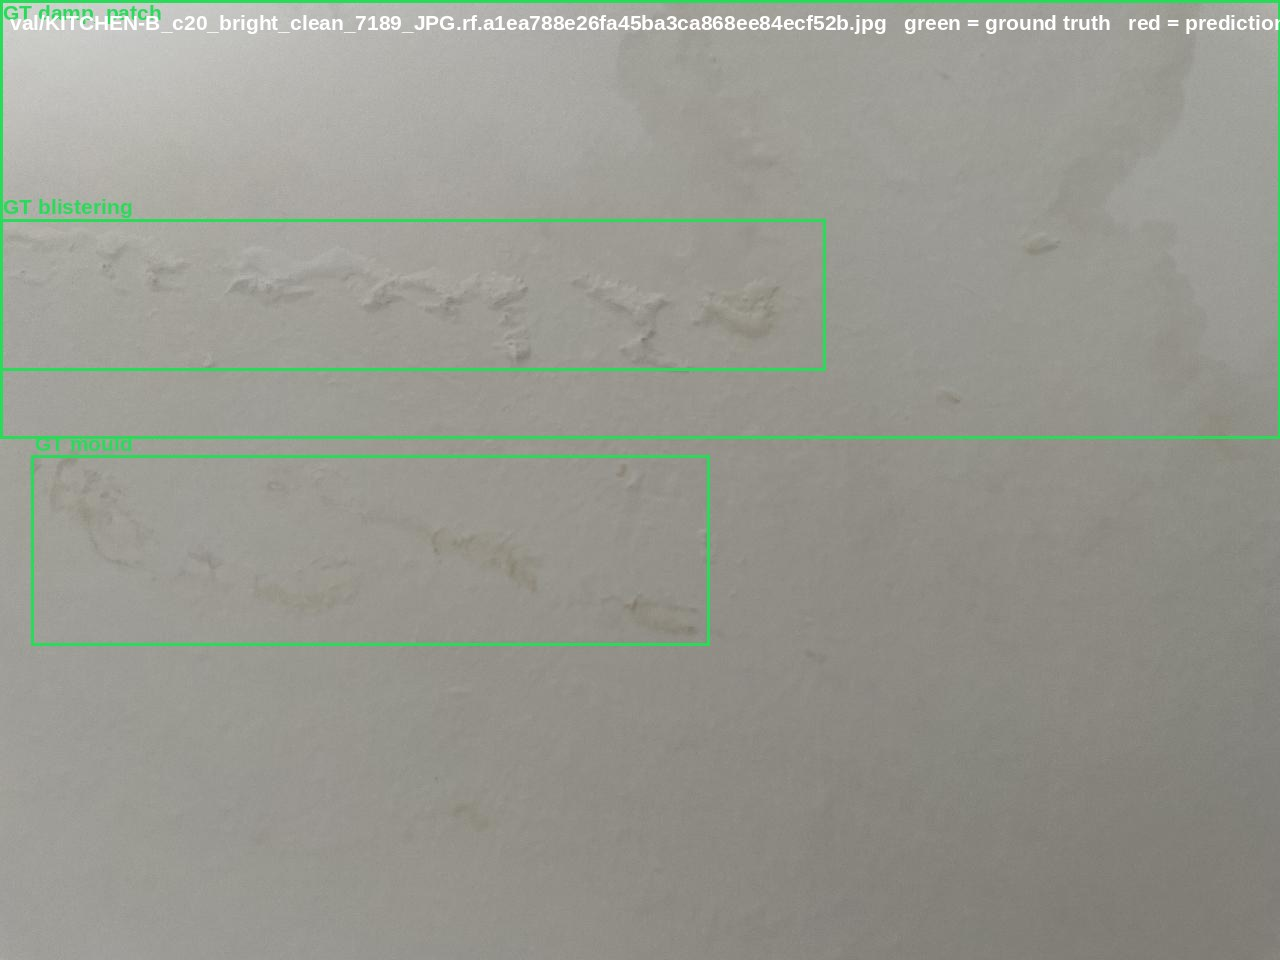


=== FN: val_KITCHEN-D_c40_bright_clean_7166_JPG.rf.5e59da9f863b6b28e112c06e3bfcc1ad_overlay.jpg ===


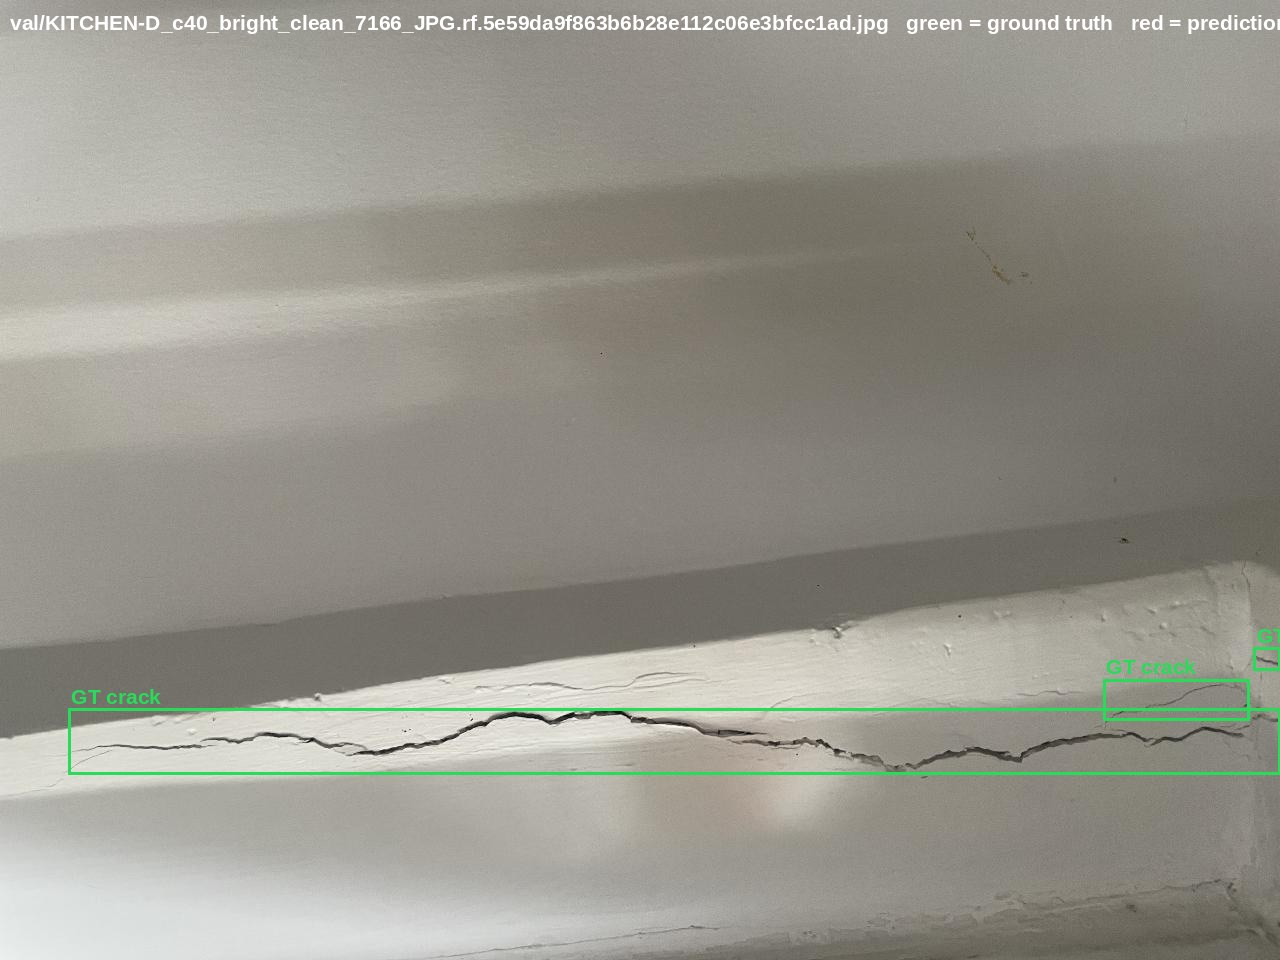


=== FN: test_LIVING-B_c20_bright_clean_7172_JPG.rf.9139775213779cfa4070ebd0fa77d72c_overlay.jpg ===


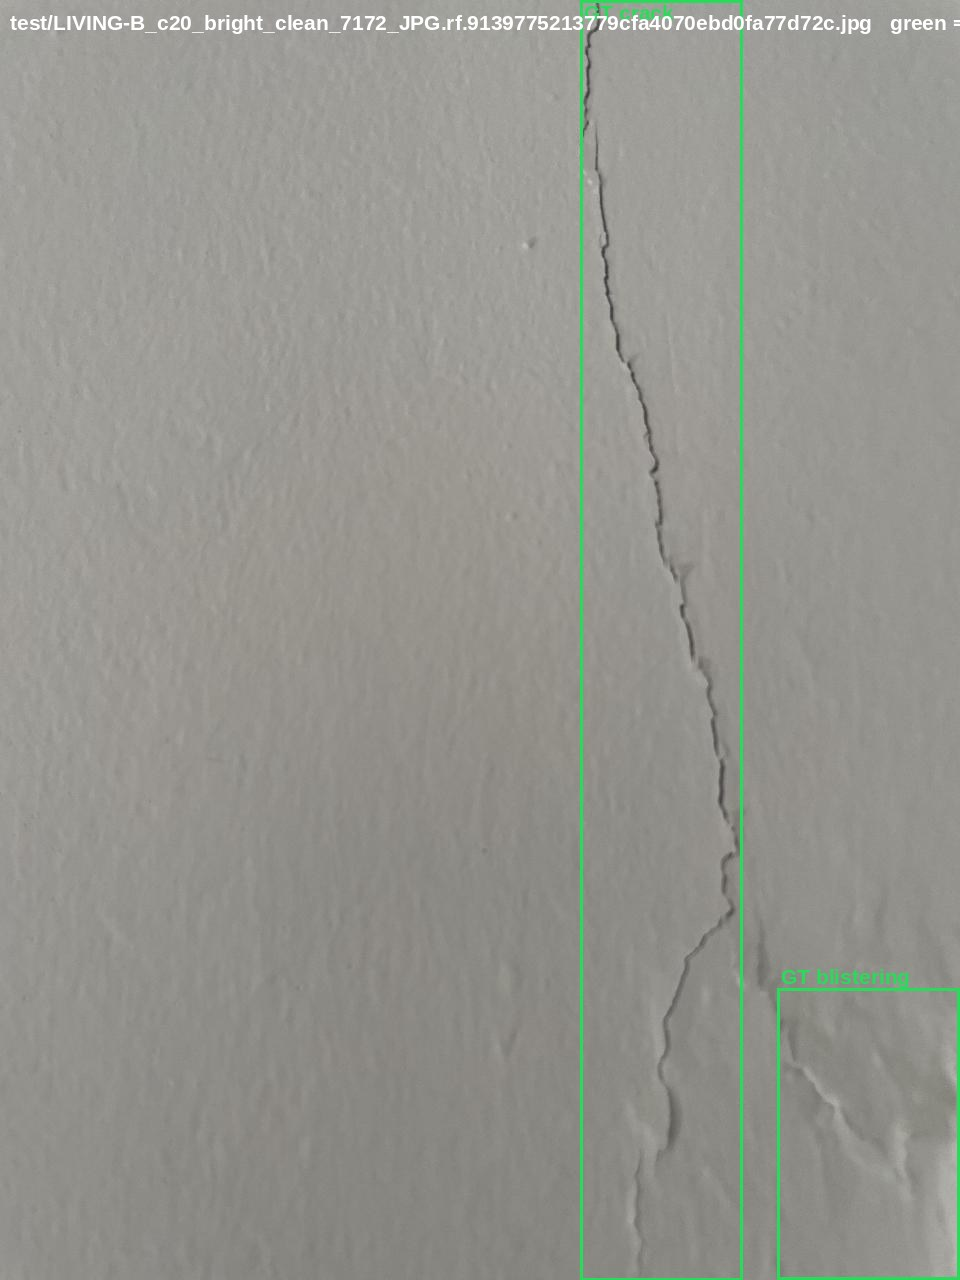


=== FP: val_HALLWAY-A_c40_bright_clean_7108_JPG.rf.08a505b21c7ddff4dfea9ee90bfeab6a_overlay.jpg ===


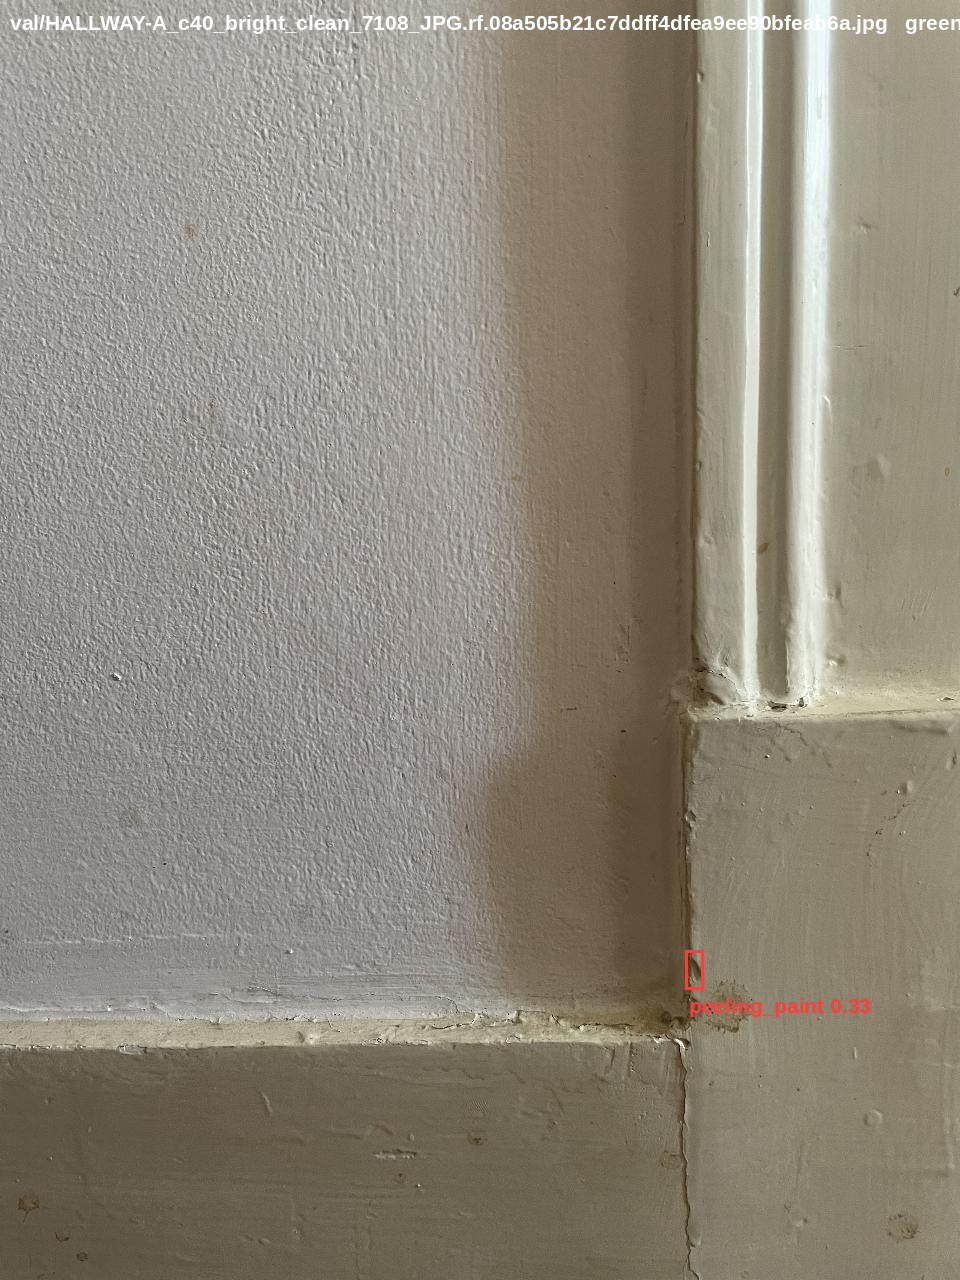


=== FP: test_LIVING-A_c20_bright_clean_7110_JPG.rf.ec781ebba7510fe7051c6cc67286c788_overlay.jpg ===


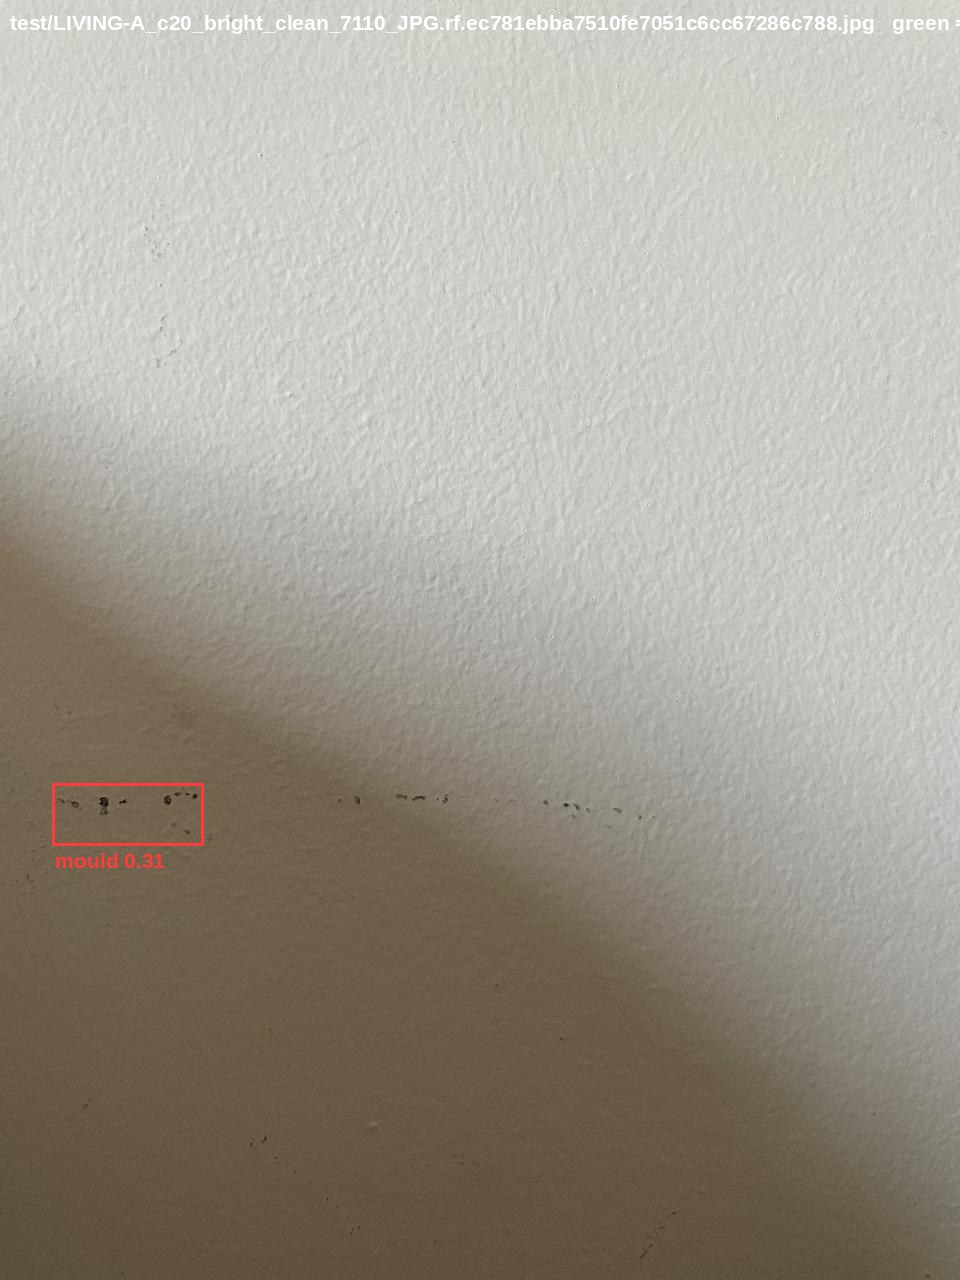


=== FP: test_LIVING-C_c10_bright_clean_7134_JPG.rf.5d5c936960ad97e4a674a467e3761d76_overlay.jpg ===


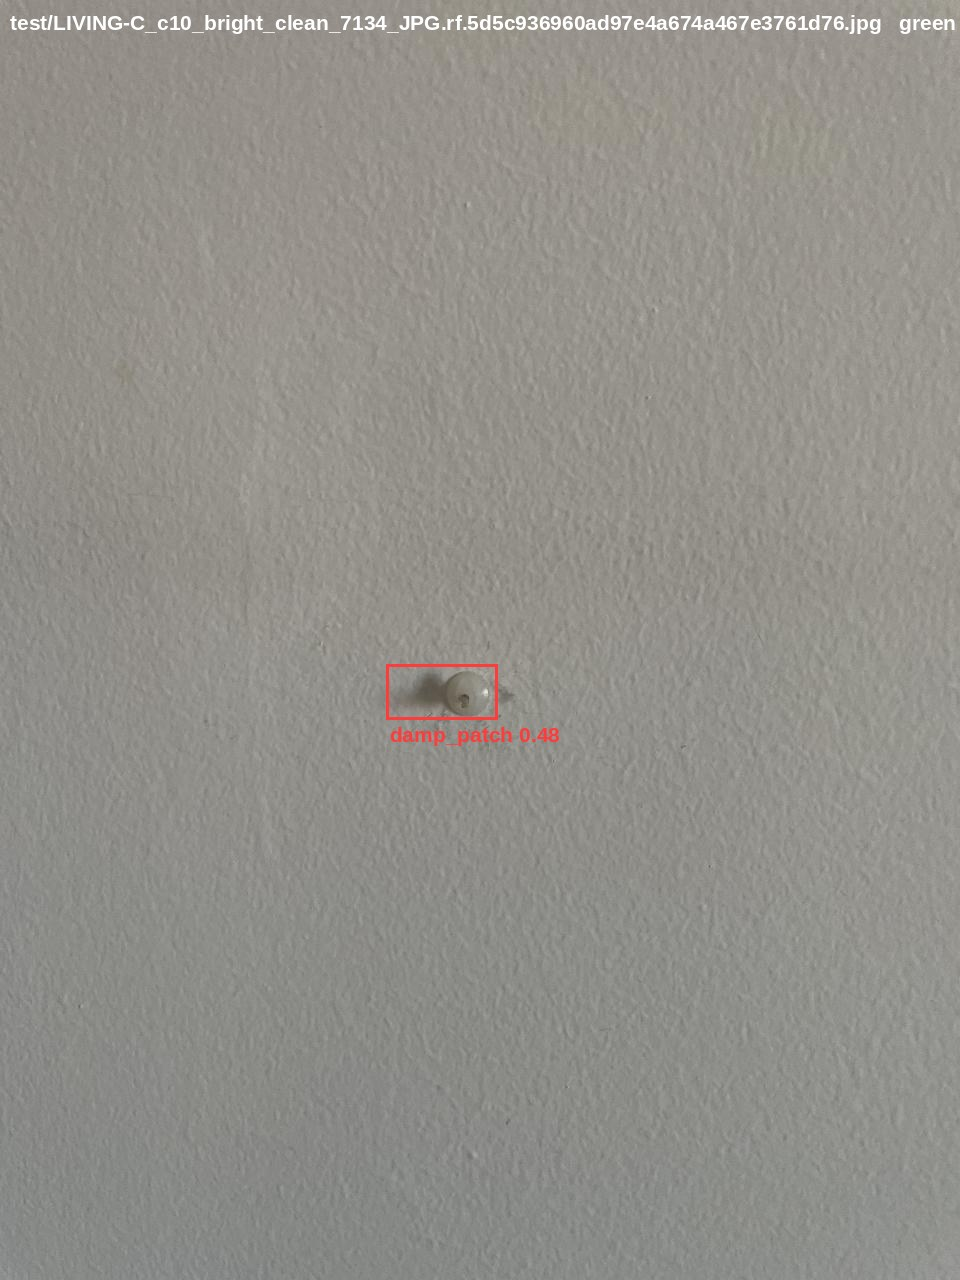


=== FP: test_OFFICE-A_c10_elec_clean_7113_JPG.rf.465cfb4e071c8f357005b432d62f471e_overlay.jpg ===


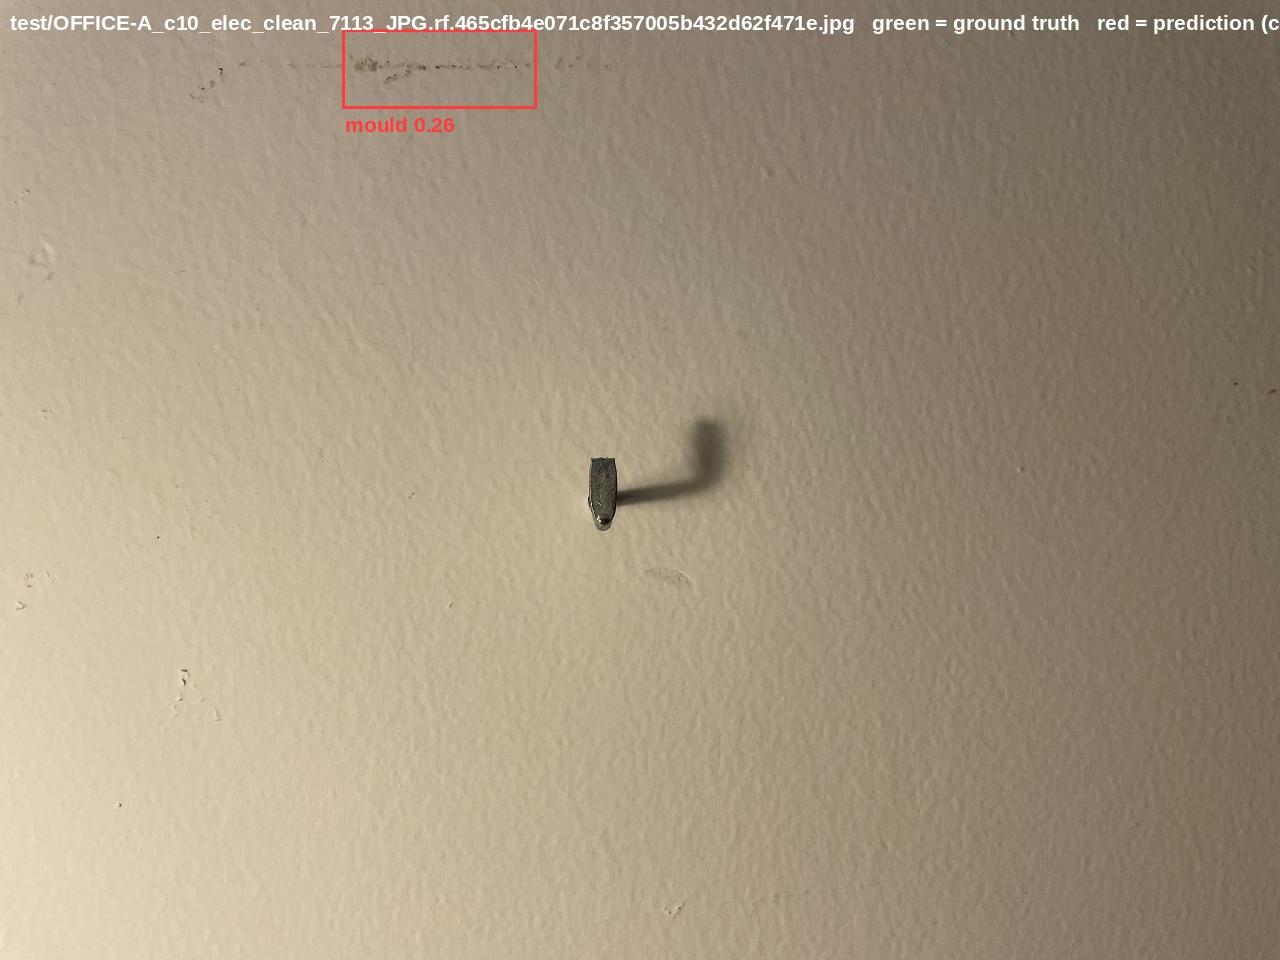

In [10]:
from IPython.display import Image as IPyImage, display as ipy_display

for tag, p in produced[:9]:
    print(f"\n=== {tag}: {p.name} ===")
    ipy_display(IPyImage(filename=str(p), width=820))

**Choosing from these for `docs/error_analysis.md`.** Take one of each, and write the caption
to say what the image *shows*, not what it is. "FN-1: near-floor damp, three annotated boxes,
no prediction above 0.25 — the lower wall appears in training almost exclusively as hard
negatives" is a finding. "Example of a false negative" is a label.


---
## **8. Confidence threshold sweep**

`conf = 0.25` is a default, not a decision. For a screening tool the threshold is a policy
choice: every class in `class_definitions.md` was specified **recall-priority**, because a
missed defect is a defect behind a wall somebody is about to sign for, while a false alarm
costs a second look.

This sweep re-scores the *same* predictions at a range of thresholds, so the curve shows the
trade actually available from this model — not from a different inference pass.

Read it for the shape, not for a winner. If recall barely improves as the threshold drops, the
detections simply are not there and no operating point rescues them. If recall climbs steeply
while precision decays slowly, a lower threshold is defensible and should be stated in the
README as the recommended setting.


In [11]:
rows = []
for t in [0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    per_img, _ = account(t)
    s = per_img.groupby("split")[["gt", "pred", "TP", "FN", "FP", "confusion"]].sum()
    for split in s.index:
        tp, gt_n, pr_n = s.loc[split, "TP"], s.loc[split, "gt"], s.loc[split, "pred"]
        rows.append(dict(conf=t, split=split,
                         recall=tp / gt_n if gt_n else np.nan,
                         precision=tp / pr_n if pr_n else np.nan,
                         FN=s.loc[split, "FN"], FP=s.loc[split, "FP"],
                         confusion=s.loc[split, "confusion"]))

SWEEP = pd.DataFrame(rows)
SWEEP.to_csv(EVIDENCE / "confidence_sweep.csv", index=False)
display(SWEEP.pivot(index="conf", columns="split",
                    values=["recall", "precision"]).round(3))

recall        precision       
split   test    val      test    val
conf                                
0.02   0.205  0.455     0.022  0.068
0.05   0.096  0.347     0.021  0.112
0.10   0.027  0.253     0.012  0.173
0.15   0.027  0.185     0.018  0.202
0.20   0.014  0.149     0.013  0.245
0.25   0.014  0.105     0.020  0.264
0.30   0.000  0.077     0.000  0.286
0.40   0.000  0.055     0.000  0.426
0.50   0.000  0.030     0.000  0.478

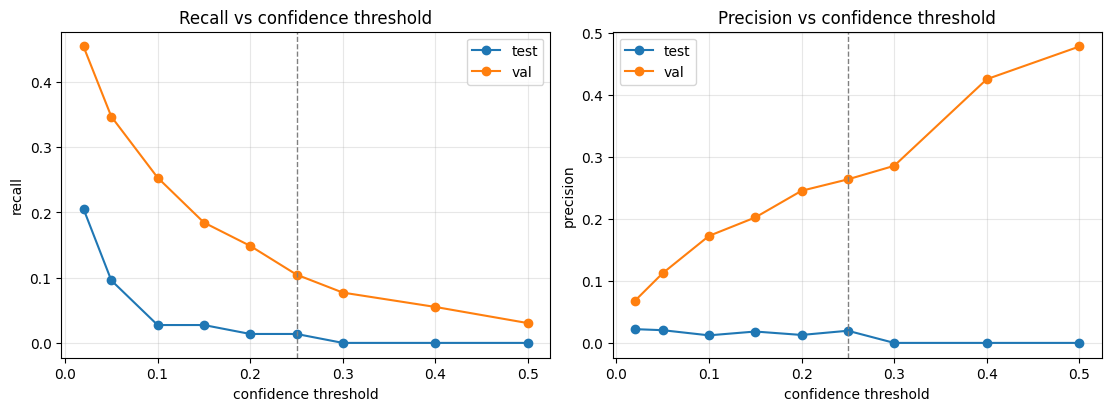

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for split, g in SWEEP.groupby("split"):
    axes[0].plot(g.conf, g.recall, marker="o", label=split)
    axes[1].plot(g.conf, g.precision, marker="o", label=split)
axes[0].set_title("Recall vs confidence threshold")
axes[1].set_title("Precision vs confidence threshold")
for ax in axes:
    ax.set_xlabel("confidence threshold")
    ax.axvline(CONF, color="grey", ls="--", lw=1)
    ax.grid(alpha=.3)
    ax.legend()
axes[0].set_ylabel("recall")
axes[1].set_ylabel("precision")
fig.savefig(EVIDENCE / "confidence_sweep.png", dpi=150)
plt.show()

---
## **9. The holdout frames**

Twelve frames that were **never uploaded to Roboflow**, never annotated, and never part of any
split. They are the only images in this project the model has no relationship with of any kind.

There is no ground truth, so nothing here can be scored. That is the point: it is a qualitative
check of whether the model produces anything sensible on genuinely fresh input, and it is the
closest thing in this project to a field trial.

Skipped silently if the frames are not present, so *Run All* never breaks.


In [13]:
HOLDOUT_DIR = ROOT / "holdout"

if HOLDOUT_URL and not HOLDOUT_DIR.exists():
    hz = ROOT / "holdout.zip"
    try:
        fetch(HOLDOUT_URL, hz)
        HOLDOUT_DIR.mkdir(exist_ok=True)
        with zipfile.ZipFile(hz) as z:
            z.extractall(HOLDOUT_DIR)
    except Exception as e:
        print(f"could not fetch holdout: {e}")

if not HOLDOUT_DIR.exists():
    print("No holdout frames present — skipping (this is not an error).")
    print(f"Upload a folder named 'holdout' to {ROOT}, or set HOLDOUT_URL.")
else:
    hold = sorted(p for p in HOLDOUT_DIR.rglob("*") if p.suffix.lower() in IMG_EXT)
    print(f"{len(hold)} holdout frames")
    out_dir = EVIDENCE / "holdout_predictions"
    out_dir.mkdir(parents=True, exist_ok=True)

    hrows = []
    res = model.predict(source=[str(p) for p in hold], imgsz=IMGSZ,
                        conf=CONF, iou=IOU_NMS, verbose=False, stream=True)
    for p, r in zip(hold, res):
        n = len(r.boxes) if r.boxes is not None else 0
        counts = {}
        if n:
            for c, cf in zip(r.boxes.cls.cpu().numpy().astype(int),
                             r.boxes.conf.cpu().numpy()):
                counts.setdefault(NAMES[int(c)], []).append(float(cf))
        hrows.append(dict(image=p.name, detections=n,
                          classes="; ".join(f"{k}x{len(v)} (max {max(v):.2f})"
                                            for k, v in counts.items()) or "—"))
        Image.fromarray(r.plot()[:, :, ::-1]).save(out_dir / f"{p.stem}_pred.jpg", quality=88)

    HOLD = pd.DataFrame(hrows)
    display(HOLD)
    HOLD.to_csv(EVIDENCE / "holdout_predictions.csv", index=False)

    for p in sorted(out_dir.glob("*_pred.jpg"))[:6]:
        print(f"\n=== {p.name} ===")
        ipy_display(IPyImage(filename=str(p), width=820))

No holdout frames present — skipping (this is not an error).
Upload a folder named 'holdout' to /content, or set HOLDOUT_URL.


**How to report this.** The holdout frames concentrate on near-floor regions, which
`class_definitions.md` flagged before training as under-represented — the lower wall appears in
the training split mainly as hard negatives. Weak performance here was predicted in advance,
which makes it evidence for the coverage-gap explanation rather than a fresh surprise.

Say how many of the twelve produced any detection at all, and resist reading the boxes as
correct or incorrect: with no annotations there is no ground truth to be correct against. This
is an observation, not a measurement.


---
## **10. Evidence pack**


In [14]:
import json as _json

record = {
    "notebook": "02_Inference.ipynb",
    "dataset_url": DATASET_URL,
    "dataset_sha256": DATASET_SHA256.lower(),
    "model_url": MODEL_URL,
    "model_sha256": model_digest,
    "model_from_release": bool(got_remote),
    "imgsz": IMGSZ,
    "conf_floor": CONF_FLOOR,
    "conf_reported": CONF,
    "iou_match": IOU_MATCH,
    "iou_nms": IOU_NMS,
    "classes": list(NAMES.values()) if isinstance(NAMES, dict) else list(NAMES),
    "ultralytics_version": ultralytics.__version__,
    "torch_version": torch.__version__,
    "device": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu",
    "totals_at_reported_conf": summary.reset_index().to_dict(orient="records"),
}
(EVIDENCE / "inference_record.json").write_text(_json.dumps(record, indent=2, default=str))
print(_json.dumps(record, indent=2, default=str))

shutil.make_archive(str(ROOT / "evidence_inference"), "zip", EVIDENCE)
print(f"\nwrote {ROOT / 'evidence_inference.zip'}")
for p in sorted(EVIDENCE.rglob("*")):
    if p.is_file():
        print(f"  {str(p.relative_to(EVIDENCE)):<46}{p.stat().st_size/1024:>8.0f} KB")

try:
    from google.colab import files
    files.download(str(ROOT / "evidence_inference.zip"))
except Exception as e:
    print(f"\n(not in Colab, or download blocked: {e})")

{
  "notebook": "02_Inference.ipynb",
  "dataset_url": "https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/interior-wall-defects-v1-yolo11.zip",
  "dataset_sha256": "9137b89d2f406adf1fa7dbfc6bf5a2e95db396d39c26a8c80d248a2f0b8b8a42",
  "model_url": "https://github.com/JBA69/interior-wall-defects/releases/download/v1.0/best-run2.pt",
  "model_sha256": "cc1d5096124f32bc7783d86a817394fc08501ef8291b2fa6c76f9dc1e720fe4f",
  "model_from_release": true,
  "imgsz": 1280,
  "conf_floor": 0.01,
  "conf_reported": 0.25,
  "iou_match": 0.45,
  "iou_nms": 0.7,
  "classes": [
    "blistering",
    "crack",
    "damp_patch",
    "mould",
    "peeling_paint"
  ],
  "ultralytics_version": "8.4.166",
  "torch_version": "2.11.0+cpu",
  "device": "cpu",
  "totals_at_reported_conf": [
    {
      "split": "test",
      "gt": 73,
      "pred": 51,
      "TP": 1,
      "FN": 72,
      "FP": 50,
      "confusion": 7,
      "recall": 0.014,
      "precision": 0.02
    },
    {
      "split": 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

## **What to take from this notebook**

- `per_image_errors.csv` — the ranking behind every example cited in the error analysis.
- `overlays/` — the figures for the three evidence slots in `docs/error_analysis.md`.
- `confidence_sweep.csv` / `.png` — the operating-point argument.
- `holdout_predictions/` — the qualitative check on frames nothing has ever seen.

**Screening, not certification.** This model indicates where a surveyor should look. It does
not assess severity, depth, moisture content, or structural significance, and its output is not
a condition report.
